|<h2>Course:</h2>|<h1><a href="https://udemy.com/course/deeplearning_x/?couponCode=202508" target="_blank">A deep understanding of deep learning</a></h1>|
|-|:-:|
|<h2>Section:</h2>|<h1>Autoencoders<h1>|
|<h2>Lecture:</h2>|<h1><b>AEs for occlusions<b></h1>|

<br>

<h5><b>Teacher:</b> Mike X Cohen, <a href="https://sincxpress.com" target="_blank">sincxpress.com</a></h5>
<h5><b>Course URL:</b> <a href="https://udemy.com/course/deeplearning_x/?couponCode=202508" target="_blank">udemy.com/course/deeplearning_x/?couponCode=202508</a></h5>
<i>Using the code without the course may lead to confusion or errors.</i>

In [1]:
# import libraries
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets

import copy

import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

# Import and process the data

In [2]:
# download MNIST dataset
output_dir = 'sample_data'
mnist = datasets.MNIST(root='sample_data', download=True)

# extract labels (number IDs) and data
labels = mnist.targets.numpy()
data = mnist.data.numpy().reshape(mnist.data.shape[0], -1)  # flatten to 2D

# normalize the data to a range of [0 1]
dataNorm = data / np.max(data)

# convert to tensor
dataT = torch.tensor( dataNorm ).float()

print(labels.shape)
print(data.shape)

(60000,)
(60000, 784)


# Demonstration of implementing occlusion

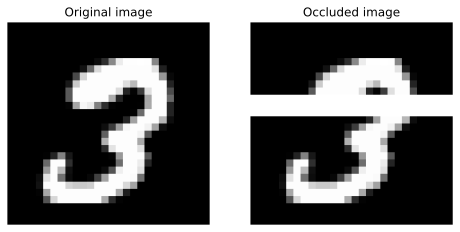

In [3]:
# reconstruct a sample as an image

img = dataT[12345,:].view(28,28)


occluded = copy.deepcopy( img )
occluded[10:13,:] = 1

fig,ax = plt.subplots(1,2,figsize=(8,5))

ax[0].imshow(img,cmap='gray')
ax[0].set_title('Original image')
ax[0].axis('off')

ax[1].imshow(occluded,cmap='gray')
ax[1].set_title('Occluded image')
ax[1].axis('off')

plt.show()

# Create the DL model

In [4]:
# create a class for the model
def createTheMNISTAE():

  class aenet(nn.Module):
    def __init__(self):
      super().__init__()

      ### input layer
      self.input = nn.Linear(784,128)

      ### encoder layer
      self.enc = nn.Linear(128,50)

      ### latent layer
      self.lat = nn.Linear(50,128)

      ### decoder layer
      self.dec = nn.Linear(128,784)

    # forward pass
    def forward(self,x):
      x = F.relu( self.input(x) )
      x = F.relu( self.enc(x) )
      x = F.relu( self.lat(x) )
      y = torch.sigmoid( self.dec(x) )
      return y

  # create the model instance
  net = aenet()

  # loss function
  lossfun = nn.MSELoss()

  # optimizer
  optimizer = torch.optim.Adam(net.parameters(),lr=.001)

  return net,lossfun,optimizer

# Create a function that trains the model

In [5]:
def function2trainTheModel():

  # number of epochs
  numepochs = 5

  # create a new model
  net,lossfun,optimizer = createTheMNISTAE()

  # initialize losses
  losses = []



  # batch size and number of batches
  batchsize  = 32
  numBatches = int(dataT.shape[0]/batchsize)


  # loop over epochs (now each epoch goes through all samples)
  for epochi in range(numepochs):


    # get a permuted index vector
    randidx = np.random.permutation(dataT.shape[0]).astype(int)

    for batchi in range(numBatches):

      # samples to use in this batch
      samps2use = range((batchi-1)*batchsize,batchi*batchsize)


      # select those images
      X = dataT[randidx[samps2use],:]

      # forward pass and loss
      yHat = net(X)
      loss = lossfun(yHat,X)

      # backprop
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()


      # losses in this batch
      losses.append( loss.item() )

  # end epochs

  # function output
  return losses,net

# Run the model and show the results!

Final loss: 0.0077


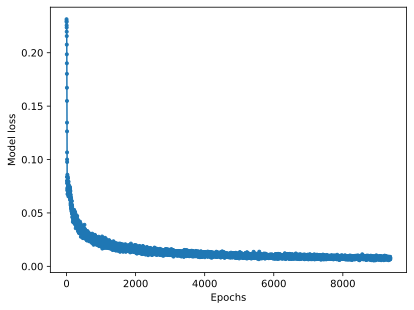

In [6]:
# train the model (16s)
losses,net = function2trainTheModel()
print(f'Final loss: {losses[-1]:.4f}')

# visualize the losses
plt.plot(losses,'.-')
plt.xlabel('Epochs')
plt.ylabel('Model loss')
plt.show()

# Add occlusion to some images

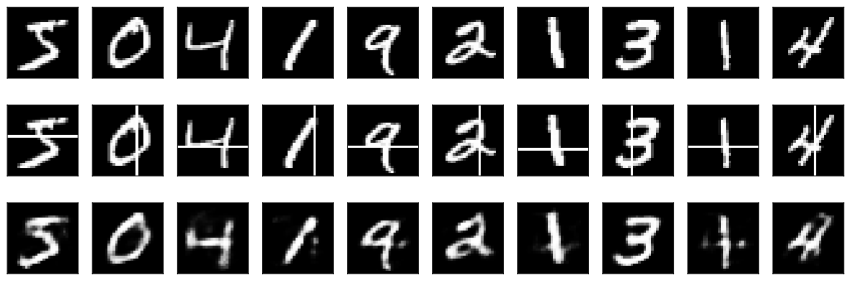

In [7]:
# grab a small set of images
X = copy.deepcopy( dataT[:10,:] )

def occlude_image(X):
  # add noise
  for i in range(X.shape[0]):

    # reshape the image
    img = X[i,:].view(28,28)

    # occlude random rows or columns
    startloc = np.random.choice(range(10,21))
    if i%2==0: # even -> horizontal occlusion
      img[startloc:startloc+1,:] = 1
    else:      # odd -> vertical occlusion
      img[:,startloc:startloc+1] = 1
  
  return X

X = occlude_image(X)


# run the samples through the model
deOccluded = net(X)


# show the noisy images
fig,axs = plt.subplots(3,10,figsize=(15,5))

for i in range(10):
  axs[0,i].imshow(dataT[i,:].view(28,28).detach() ,cmap='gray')
  axs[1,i].imshow(X[i,:].view(28,28).detach() ,cmap='gray')
  axs[2,i].imshow(deOccluded[i,:].view(28,28).detach() ,cmap='gray')
  axs[0,i].set_xticks([]), axs[0,i].set_yticks([])
  axs[1,i].set_xticks([]), axs[1,i].set_yticks([])
  axs[2,i].set_xticks([]), axs[2,i].set_yticks([])

plt.show()

# Something more quantitative

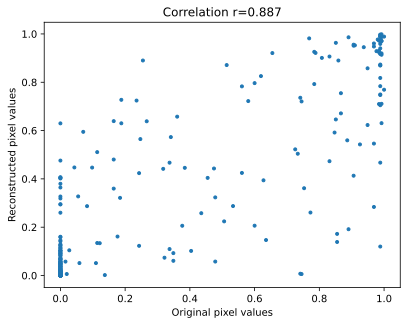

In [8]:
# We can quantify the performance of our "de-occluder" by correlating the sample with the original.

inOutCorr = np.corrcoef(dataT[9,:].detach(),deOccluded[9,:].detach())

# and plot
plt.plot(dataT[9,:].detach(),deOccluded[9,:].detach(),'.')
plt.xlabel('Original pixel values')
plt.ylabel('Reconstructed pixel values')
plt.title(f'Correlation r={ inOutCorr[0,1] :.3f}')
plt.show()

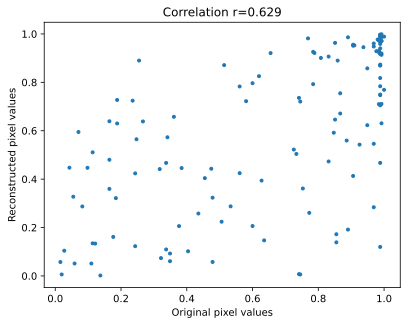

In [9]:
# try again without the zero-valued pixels

# extract to variables for convenience
orig  = dataT[9,:].detach()
recon = deOccluded[9,:].detach()

# boolean vector that indicates pixels>0 (with some tolerance)
tol = 1e-4
nonzeropixels = (orig>tol) & (recon>tol)

# then re-compute the correlation
inOutCorr = np.corrcoef(orig[nonzeropixels],recon[nonzeropixels])

# redraw the previous plot
plt.plot(orig[nonzeropixels],recon[nonzeropixels],'.')
plt.xlabel('Original pixel values')
plt.ylabel('Reconstructed pixel values')
plt.title(f'Correlation r={ inOutCorr[0,1] :.3f}')
plt.show()

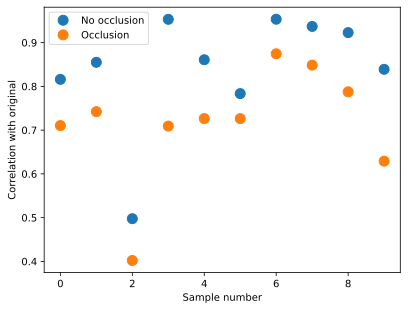

In [10]:
# get data with no occlusion
noOcclusion = net(dataT[:10,:])

# compare deOccluded-original to noOcclusion-original correlation
r = np.zeros((10,2))
for i in range(deOccluded.shape[0]):

  # pixel selection (note: tolerance defined in previous cell)
  nonzeropixels = (dataT[i,:]>tol) & (noOcclusion[i,:]>tol) & (deOccluded[i,:]>tol)

  # now compute the correlations
  r[i,0] = np.corrcoef(dataT[i,nonzeropixels].detach(),noOcclusion[i,nonzeropixels].detach())[0,1]
  r[i,1] = np.corrcoef(dataT[i,nonzeropixels].detach(),deOccluded[i,nonzeropixels].detach())[0,1]


# plot the correlation coefficients
plt.plot(r,'o',markersize=10)
plt.legend(['No occlusion','Occlusion'])
plt.xlabel('Sample number')
plt.ylabel('Correlation with original')
plt.show()

# Additional explorations

In [82]:
# 1) Does occlusion affect some numbers more than others? Run the entire dataset through the autoencoder with occluded
#    images. Compute the image correlations for each sample. Then compute the average correlation for each number (image
#    label). Show the results in a plot. (Bonus: Also compute the standard deviation across correlations and use those
#    to draw error bars.) What do the results tell you about the difficulty of fixing occlusions in images?
#
# 2) Perhaps a correlation coefficient isn't really the best performance metric. Try this: Binarize the images like we
#    did in the video "CodeChallenge: Binarized MNIST images" (section FFN). Then compute the number of pixels in the
#    original and reconstructed images that overlap (hint: try summing them). Make sure your new metric has a possible
#    range of 0 (absolutely no overlap) to 1 (perfect overlap). Does this metric seem more consistent with your visual
#    intuition?
#
# 3) But wait a minute, don't we already have a quantitative measure of the similarity between the AE input and output?
#    Of course we do -- it's the loss function! Mean-squared error already accounts for zeros because those get ignored
#    [zero-valued pixels have MSE=(0-0)**2 ]. In fact, question #2 is kindof a "rough MSE." Take a moment to write down
#    the formulas for MSE and correlation, and see whether they are related (hint: the relationship isn't linear because of
#    the squared term). Finally, compute MSE on our example occlusion images and compare MSE to correlation empirically
#    by making a scatter plot. (Hint 1: Use more than 10 examples to see trends. Hint 2: Consider the signs (+/-).)
#
# Note about exercises 2&3: MSE really is the best loss function for this problem. The purpose of these exercises is to
#    get you thinking critically about autoencoders, loss functions, and the idea of using custom-designed quantitative
#    comparisons measures. I hope you find these problems enjoyable and thought-provoking!
#

In [83]:
# 1) Does occlusion affect some numbers more than others? Run the entire dataset through the autoencoder with occluded
#    images. Compute the image correlations for each sample. Then compute the average correlation for each number (image
#    label). Show the results in a plot. (Bonus: Also compute the standard deviation across correlations and use those
#    to draw error bars.) What do the results tell you about the difficulty of fixing occlusions in images?
# Answer: The corrlation between from occlusion reconstructed images and original images varies depending on the digit.
# For the neuronal network beeing correct as possible - the vasriataion of correlation per digit shall be learned as precise as possible.
# It could lead to overfitting on some digits and underfitting on others especially for not-seen ones.
#

orig = copy.deepcopy( dataT )
X = copy.deepcopy( dataT )
X = occlude_image(X)
recon = net(X).detach()

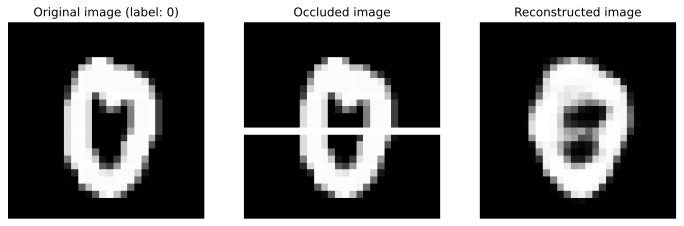

In [84]:
idx = np.random.choice( range(dataT.shape[0]) )
img_orig = orig[idx,:].view(28,28)
img_occluded = X[idx,:].view(28,28)
img_recon = recon[idx,:].view(28,28)

fig,ax = plt.subplots(1,3,figsize=(12,5))

ax[0].imshow(img_orig,cmap='gray')
ax[0].set_title(f'Original image (label: {labels[idx]})')
ax[0].axis('off')

ax[1].imshow(img_occluded,cmap='gray')
ax[1].set_title('Occluded image')
ax[1].axis('off')

ax[2].imshow(img_recon,cmap='gray')
ax[2].set_title('Reconstructed image')
ax[2].axis('off')

plt.show()

In [85]:
# Compute the image correlations for each sample

r = np.zeros(recon.shape[0])
tol = 1e-4
for i in range(recon.shape[0]):
  nonzeropixels = (orig[i,:]>tol) & (recon[i,:]>tol) # pixel selection
  r[i] = np.corrcoef(orig[i,nonzeropixels], recon[i,nonzeropixels])[0,1]  # now compute the correlations

# plot the correlation coefficients
fig = plt.figure(figsize=(12,6))
plt.hist(r, bins=max(30, int(recon.shape[0]*1e-3)))
plt.ylabel('Sample number')
plt.xlabel('Correlation with original')
plt.show()

/home/nuke/Documents/dev/.work_py_venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/nuke/Documents/dev/.work_py_venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


KeyboardInterrupt: 

[[0.90051191 0.04350623]
 [0.89128019 0.04999319]
 [0.8706864  0.05672301]
 [0.88132913 0.05090885]
 [0.87337136 0.05431399]
 [0.85980787 0.06021171]
 [0.87179877 0.0573149 ]
 [0.8854196  0.05022054]
 [0.85631955 0.0599859 ]
 [0.88093201 0.05347286]]


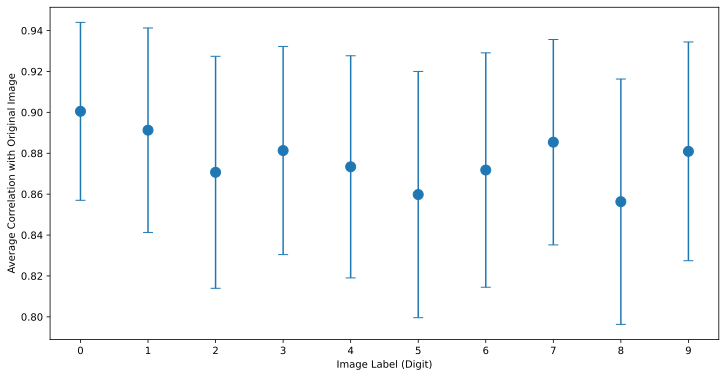

In [ ]:
# Compute the average correlation for each number (image label)

r = np.zeros(recon.shape[0])
tol = 1e-4
for i in range(recon.shape[0]):
  nonzeropixels = (orig[i,:]>tol) + (recon[i,:]>tol) # pixel selection
  r[i] = np.corrcoef(orig[i,nonzeropixels], recon[i,nonzeropixels])[0,1]  # now compute the correlations
  # r[i] = np.corrcoef(orig[i,:], recon[i,:])[0,1]

unique_labels = np.unique(labels)
r_per_class = np.zeros((unique_labels.shape[0], 2))  # mean and std_dev of the correlations
for classi, label in enumerate(unique_labels):
    class_samples = (labels == label)
    r_per_class[classi, 0] = np.mean(r[class_samples])
    r_per_class[classi, 1] = np.std(r[class_samples])

print(r_per_class)

# # Plot the correlation coefficients per class and stddiv
fig = plt.figure(figsize=(12,6))
plt.errorbar(unique_labels, r_per_class[:,0], yerr=r_per_class[:,1], fmt='o', markersize=10, capsize=5)
plt.xticks(unique_labels)
plt.xlabel('Image Label (Digit)')
plt.ylabel('Average Correlation with Original Image')
plt.show()

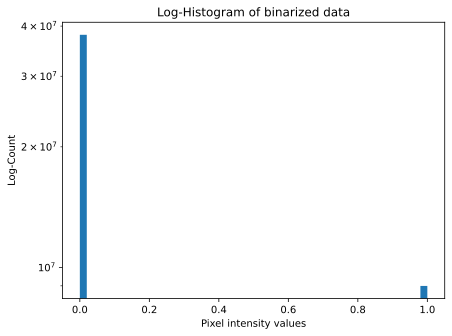

In [ ]:
# 2) Perhaps a correlation coefficient isn't really the best performance metric. Try this: Binarize the images like we
#    did in the video "CodeChallenge: Binarized MNIST images" (section FFN). Then compute the number of pixels in the
#    original and reconstructed images that overlap (hint: try summing them). Make sure your new metric has a possible
#    range of 0 (absolutely no overlap) to 1 (perfect overlap). Does this metric seem more consistent with your visual
#    intuition?
# Answer: No.

dataBin = copy.deepcopy( dataT ).numpy()
dataBin = (dataBin > 0).astype(int) # binarize the data

fig,ax = plt.subplots()
ax.hist(dataBin.flatten(),50)
ax.set_xlabel('Pixel intensity values')
ax.set_ylabel('Log-Count')
ax.set_yscale('log')
ax.set_title('Log-Histogram of binarized data')
fig.tight_layout()
plt.show()

In [ ]:
orig = torch.Tensor(copy.deepcopy( dataBin ))
X = copy.deepcopy( orig )
X = occlude_image(X)
recon = net(X).detach()

In [ ]:
pix_sum = orig.numpy() + recon.numpy()
pix_sum_overlap_idxs = pix_sum > 1  # pixels that overlap

tol = .5
new_metric = np.sum(pix_sum_overlap_idxs) / (np.sum(orig.numpy() > 0) + np.sum(recon.numpy() > tol))

print(new_metric)

0.5053917154327328


In [ ]:
# 3) But wait a minute, don't we already have a quantitative measure of the similarity between the AE input and output?
#    Of course we do -- it's the loss function! Mean-squared error already accounts for zeros because those get ignored
#    [zero-valued pixels have MSE=(0-0)**2 ]. In fact, question #2 is kindof a "rough MSE." Take a moment to write down
#    the formulas for MSE and correlation, and see whether they are related (hint: the relationship isn't linear because of
#    the squared term). Finally, compute MSE on our example occlusion images and compare MSE to correlation empirically
#    by making a scatter plot. (Hint 1: Use more than 10 examples to see trends. Hint 2: Consider the signs (+/-).)
# Answer:
#

In [100]:
# Source - https://stackoverflow.com/a
# Posted by minrk, modified by community. See post 'Timeline' for change history
# Retrieved 2026-01-05, License - CC BY-SA 4.0

from IPython.display import display, Math, Latex

# Explain variables in MSE formula
display(Math(r'\text{MSE} = \frac{1}{n} \sum_{i=1}^n (y_i - \hat{y}_i)^2'))
display(Latex(r'$n$: Total number of data points. $y_i$: Actual value of the $i^{th}$ data point.'))
display(Latex(r'$\hat{y}_i$: Predicted value of the $i^{th}$ data point.'))
display(Latex(r'$(y_i - \hat{y}_i)^2$: Squared difference between the actual and predicted values for the $i^{th}$ data point.'))

# Explain variables in correlation coefficient formula
display(Math(r'r = \frac{\sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^n (x_i - \bar{x})^2} \sqrt{\sum_{i=1}^n (y_i - \bar{y})^2}}'))
display(Latex(r'$n$: Total number of data points. $x_i$: Value of the $i^{th}$ data point in the first dataset.'))
display(Latex(r'$y_i$: Value of the $i^{th}$ data point in the second dataset.'))
display(Latex(r'$\bar{x}$: Mean of the first dataset. $\bar{y}$: Mean of the second dataset.'))

<IPython.core.display.Math object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Math object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>